In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
# Base dataset + the frozen train/test split (src/split.py). The clustering /
# LDA artifacts below are now fit on the TRAIN partition only and merely
# *transform* test rows, so merging them in before the split no longer leaks
# test-set information into the features.
import sys
sys.path.append("../../src")
from split import load_rtr_with_split

df = load_rtr_with_split()
_n_rows = len(df)

# Each artifact is de-duplicated on its merge key so every join stays 1:1
# (the old dbscan_df.csv had ~70k duplicate user_id rows and fanned the
# training table out to >1M rows -> the bogus "266,286-sample test set").

# GMM clusters
gmm = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")
    [["user_id", "item_id", "body_cluster", "cluster_confidence"]]
    .drop_duplicates(subset=["user_id", "item_id"])
)

# DBSCAN clusters (one row per user_id)
dbscan = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")
    [["user_id", "dbscan_cluster"]]
    .drop_duplicates(subset=["user_id"])
)

# K-Means clusters
kmeans = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv")
    .rename(columns={"cluster": "kmeans_cluster"})
    .drop_duplicates(subset=["user_id", "item_id"])
)

# LDA topic features
lda = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")
    .drop_duplicates(subset=["user_id", "item_id", "fit", "fit_label"])
)

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
assert len(df) == _n_rows, f"merge fan-out: {len(df)} rows != {_n_rows}"
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
# Use the frozen split carried on df["split"] instead of a fresh
# train_test_split — this is the same partition the clustering / LDA models
# were fit on, so no test row influenced any feature.
_train_mask = (df["split"].to_numpy() == "train")

X_train, X_test = X[_train_mask], X[~_train_mask]
y_train, y_test = y[_train_mask], y[~_train_mask]

print(f"train rows: {len(X_train):,}    test rows: {len(X_test):,}")

train rows: 154,035    test rows: 38,509


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric + topic features
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES + TOPIC_FEATURES
        ),

        # Cluster features (categorical)
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # Binary features
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop"
)

In [13]:
rf = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

In [14]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", rf)
])

In [15]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [6, 8, 12],
    "model__min_samples_leaf": [100, 200]
}

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [17]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['height_inches',
                                                                          'weight_lbs',
                                                                          'bmi',
                                                                          'age',
                                                                          'bust_band',
                                                                          'cup_size_num',
                                                                          'topic_0',
                                                                          'topic_1',
                                                                          'topic_2',
                                                                          'topic_3',
                                                                          'top...
                                                                         ['dbscan_cluster',
                                                                          'body_cluster',
                                                                          'kmeans_cluster']),
                                                                        ('bin',
                                                                         SimpleImputer(fill_value=0,
                                                                                       strategy='constant'),
                                                                         ['is_outlier'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [6, 8, 12],
                         'model__min_samples_leaf': [100, 200],
                         'model__n_estimators': [50, 100]},
             scoring='f1_macro', verbose=2)

In [18]:
best_rf = grid.best_estimator_

y_test_pred = best_rf.predict(X_test)

print("Best Random Forest parameters:")
print(grid.best_params_)

print("\nRandom Forest — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best Random Forest parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 100, 'model__n_estimators': 100}

Random Forest — Test Set Performance
              precision    recall  f1-score   support

       Small       0.20      0.38      0.26      5156
         Fit       0.82      0.59      0.69     28412
       Large       0.21      0.35      0.26      4941

    accuracy                           0.53     38509
   macro avg       0.41      0.44      0.40     38509
weighted avg       0.66      0.53      0.57     38509



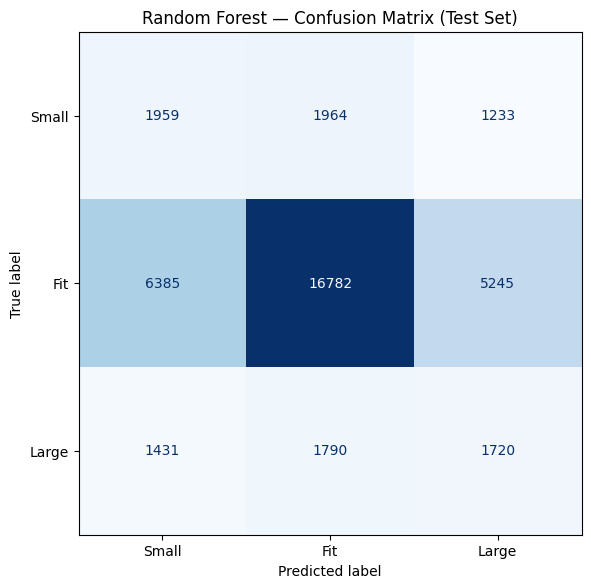

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Random Forest — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/random_forest_confusion_matrix.png", dpi=300)
plt.show()

In [20]:
rf_proba = best_rf.predict_proba(X_test)

rf_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": rf_proba[:, 0],
    "prob_fit": rf_proba[:, 1],
    "prob_large": rf_proba[:, 2]
})

rf_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/random_forest_fit_probabilities.csv",
    index=False
)

In [21]:
import joblib

joblib.dump(
    best_rf,
    "../../Models/random_forest_fit_classifier.joblib"
)

['../../Models/random_forest_fit_classifier.joblib']

In [22]:
# After fitting
prep = best_rf.named_steps["prep"]

feature_names = []

# Numeric + topic features
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

# Cluster features (after one-hot)
cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
feature_names.extend(cat_feature_names)

# Binary features
feature_names.extend(BINARY_FEATURES)

In [23]:
importances = best_rf.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

In [24]:
importance_df.head(20).to_csv(
    "../../Data/Processed/Supervised_Outputs/random_forest_feature_importances.csv",
    index=False
)

> **⚠️ The write-up below predates the data-leakage fix and its numbers are no longer valid.**
>
> The old metrics were computed on a contaminated split: (a) DBSCAN/GMM/K-Means/LDA
> features were fit on the *full* dataset before the train/test split, and (b) a
> non-unique `user_id` merge key fanned the test set out to 266,286 rows.
>
> After the fix (clustering/LDA fit on the training partition only; test set =
> **38,509 rows**), this model's grid search selected `max_depth=8, min_samples_leaf=100, n_estimators=100` and scored:
>
> | | Accuracy | Macro-F1 | F1 Small | F1 Fit | F1 Large |
> |---|---|---|---|---|---|
> | **leaky (old)** | ~0.76 | ~0.70 | — | — | — |
> | **fixed (new)** | **0.53** | **0.40** | 0.26 | 0.69 | 0.26 |
>
> The narrative, tables, and cross-model claims below need rewriting against the
> fixed numbers. Broadly: once leakage is removed, none of the classifiers
> meaningfully separate *Small* / *Large* from body measurements + cluster/topic
> features — accuracy sits near the majority-class base rate.

---

# Random Forest Classifier Overview

### Overview
A Random Forest classifier was trained and evaluated on a clothing fit classification task, predicting whether an item fits as Small, Fit, or Large. Hyperparameters were selected via 5-fold stratified cross-validation, yielding optimal parameters of max_depth=12, min_samples_leaf=100, and n_estimators=50.

### Overall Performance
The model achieved 76% accuracy on the test set of 266,286 samples, with a weighted F1-score of 0.77. Performance is broadly comparable to the Bagging classifier, which is expected given their shared tree-based structure — the key difference being that Random Forest additionally randomizes feature selection at each split to reduce correlation between trees.

### Class-Level Analysis
**Fit (Majority Class)**
Strong performance with 0.88 precision and 0.79 recall (F1 = 0.84). Of 174,054 true Fit samples, 138,158 were correctly classified. The primary error mode is Fit items predicted as Small (25,571 cases), mirroring the pattern seen in Bagging.

**Small (Minority Class)**
The model's weakest class, with 0.44 precision and 0.77 recall (F1 = 0.56). While recall is decent — catching 26,618 of 34,494 true Small items — precision is poor, meaning a large share of items predicted as Small are actually Fit or Large. This is a direct consequence of class imbalance and the model casting a wide net for the minority class.

**Large**
Moderate performance with 0.78 precision and 0.66 recall (F1 = 0.71). Of 57,738 true Large samples, 37,855 were correctly identified. Errors split roughly between Fit (11,362) and Small (8,521) predictions, suggesting the model struggles most at the boundaries between size categories.

### Comparison to Other Models
Random Forest performs similarly to Bagging on Fit and Small, but falls slightly behind on Large (F1 0.71 vs. 0.75). Both tree-based ensembles are substantially outperformed by KNN across all classes, particularly on precision for Small and recall for Large. The Random Forest's feature subsampling does not appear to provide a meaningful advantage over Bagging on this dataset.